<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2FResNet50/03_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet50 - Brain Tumor MRI Classification
SE4050 Deep Learning Assignment | Transfer learning with ResNet50
Classes: 0 = Glioma, 1 = Meningioma, 2 = No Tumor, 3 = Pituitary

## 1. Environment and Configuration

In [2]:
# Connect Colab to Google Drive so we can read the shared dataset
from google.colab import drive
drive.mount('/content/drive')

PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
!ls "{PROJECT}/Dataset"

Mounted at /content/drive
dataset  dataset_config.py


In [3]:
PROJECT = "/content/drive/MyDrive/SE4050_DL_Assignment"
DATASET = f"{PROJECT}/Dataset/dataset"

# Check the folder structure
!ls "{DATASET}"
!ls "{DATASET}/splits"
!cat "{PROJECT}/Dataset/dataset_config.py"

splits	Testing  Training
test.csv  test.gsheet  train.csv  train.gsheet	val.csv


In [4]:
# Set common training settings
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
NUM_CLASSES = 4

CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]   # index = label (0-3)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Seed:", SEED)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Batch size: 16
Epochs: 10
Seed: 42
Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


## 2. Dataset and Data Splits

In [5]:
#Load shared split CSV files
import pandas as pd

train_df = pd.read_csv(f"{DATASET}/splits/train.csv")
val_df   = pd.read_csv(f"{DATASET}/splits/val.csv")
test_df  = pd.read_csv(f"{DATASET}/splits/test.csv")

print(len(train_df), len(val_df), len(test_df))
print(train_df.columns.tolist())
print(train_df.head())

4480 1120 1600
['filepath', 'label', 'class_name']
                           filepath  label class_name
0  Training/pituitary/Tr-pi_135.jpg      3  Pituitary
1    Training/notumor/Tr-no_154.jpg      2   No Tumor
2     Training/glioma/Tr-gl_365.jpg      0     Glioma
3  Training/pituitary/Tr-pi_125.jpg      3  Pituitary
4     Training/glioma/Tr-gl_433.jpg      0     Glioma


In [6]:
#Copy images to local disk
LOCAL = "/content/data"
!mkdir -p {LOCAL}
!cp -r "{DATASET}/Training" "{DATASET}/Testing" {LOCAL}/
!ls {LOCAL}

Testing  Training


In [7]:
#Build full paths and verify files
import os

for df in (train_df, val_df, test_df):
    df["full_path"] = LOCAL + "/" + df["filepath"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = (~df["full_path"].apply(os.path.exists)).sum()
    print(f"{name}: {len(df)} images, missing files: {missing}")
    print(df["class_name"].value_counts().sort_index().to_dict())

train: 4480 images, missing files: 0
{'Glioma': 1120, 'Meningioma': 1120, 'No Tumor': 1120, 'Pituitary': 1120}
val: 1120 images, missing files: 0
{'Glioma': 280, 'Meningioma': 280, 'No Tumor': 280, 'Pituitary': 280}
test: 1600 images, missing files: 0
{'Glioma': 400, 'Meningioma': 400, 'No Tumor': 400, 'Pituitary': 400}


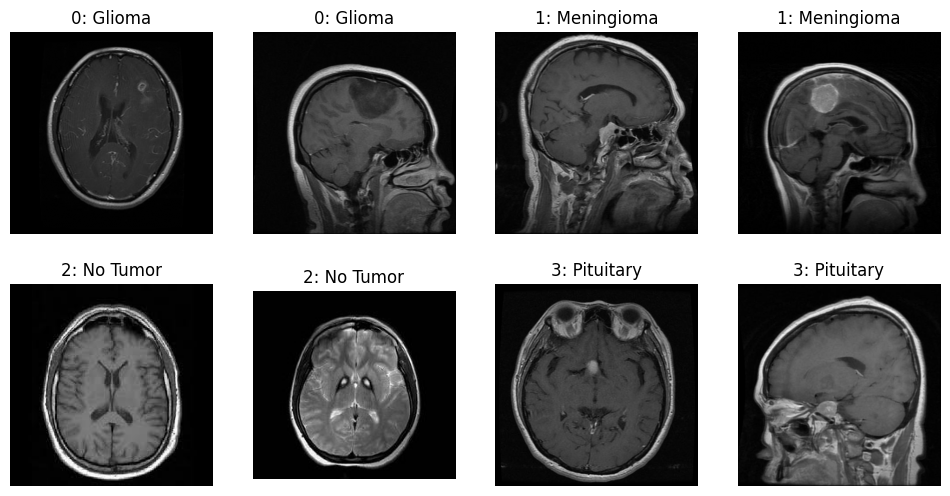

In [8]:
#Sample images per class
import matplotlib.pyplot as plt
from PIL import Image

sample = train_df.groupby("label").head(2).sort_values("label")
plt.figure(figsize=(12, 6))
for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row["full_path"]), cmap="gray")
    plt.title(f'{row["label"]}: {row["class_name"]}')
    plt.axis("off")
plt.show()

## 3. Image Preprocessing

In [9]:
#Data augmentation
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)          # pixels stay 0-255
    return img, label

def make_ds(df, training):
    ds = tf.data.Dataset.from_tensor_slices((df["full_path"].values, df["label"].values))
    if training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:   # augmentation only on training images
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y))   # ResNet50's own preprocessing, NO /255
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)
test_ds  = make_ds(test_df, training=False)

x, y = next(iter(train_ds))
print("Batch shape:", x.shape, "Labels:", y.numpy())

Batch shape: (16, 224, 224, 3) Labels: [2 3 1 2 0 2 2 1 3 2 3 1 2 1 1 2]


## 4. ResNet50 Model

In [10]:
# Loads ResNet50 pretrained on ImageNet with its backbone frozen, and adds a new
# classification head (pooling, dropout, 4-class softmax) trained with Adam (lr = 0.001).
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs, name="resnet50_brain_mri")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50_brain_mri"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 5. Model Training

In [11]:
# Sanity check: 1 epoch to confirm the pipeline and model run end to end (not the real training).
# Re-run the ResNet50 Model cell after this so Stage 1 starts from a fresh model.
model.fit(train_ds, validation_data=val_ds, epochs=1)

280/280 ━━━━━━━━━━━━━━━━━━━━ 87s 262ms/step - accuracy: 0.7786 - loss: 0.5717 - val_accuracy: 0.8687 - val_loss: 0.3478
